In [1]:
import pandas as pd
import numpy as np
import requests

from pathlib import Path

PROJECT_ROOT = Path("../")

RAW_DATA = PROJECT_ROOT/"data"/"raw"

GRID_PATH = RAW_DATA/"grid_demand"
WEATHER_PATH = RAW_DATA/"weather"
CARBON_PATH = RAW_DATA/"carbon_data"

print(GRID_PATH)
print(WEATHER_PATH)
print(CARBON_PATH)

..\data\raw\grid_demand
..\data\raw\weather
..\data\raw\carbon_data


In [2]:
import pandas as pd

grid = pd.read_csv(
    "../data/raw/grid_demand/time_series_60min_singleindex_filtered.csv"
)

print(grid.shape)

grid.columns.tolist()

(50401, 43)


['utc_timestamp',
 'cet_cest_timestamp',
 'DE_load_actual_entsoe_transparency',
 'DE_load_forecast_entsoe_transparency',
 'DE_solar_capacity',
 'DE_solar_generation_actual',
 'DE_solar_profile',
 'DE_wind_capacity',
 'DE_wind_generation_actual',
 'DE_wind_profile',
 'DE_wind_offshore_capacity',
 'DE_wind_offshore_generation_actual',
 'DE_wind_offshore_profile',
 'DE_wind_onshore_capacity',
 'DE_wind_onshore_generation_actual',
 'DE_wind_onshore_profile',
 'DE_50hertz_load_actual_entsoe_transparency',
 'DE_50hertz_load_forecast_entsoe_transparency',
 'DE_50hertz_solar_generation_actual',
 'DE_50hertz_wind_generation_actual',
 'DE_50hertz_wind_offshore_generation_actual',
 'DE_50hertz_wind_onshore_generation_actual',
 'DE_LU_load_actual_entsoe_transparency',
 'DE_LU_load_forecast_entsoe_transparency',
 'DE_LU_price_day_ahead',
 'DE_LU_solar_generation_actual',
 'DE_LU_wind_generation_actual',
 'DE_LU_wind_offshore_generation_actual',
 'DE_LU_wind_onshore_generation_actual',
 'DE_amprion_

In [3]:
selected_cols = [
    'utc_timestamp',
    'DE_load_actual_entsoe_transparency',
    'DE_solar_generation_actual',
    'DE_wind_generation_actual',
    'DE_solar_capacity',
    'DE_wind_capacity',
    'DE_LU_price_day_ahead'
]

grid_selected = grid[selected_cols]

grid_selected.head()

,utc_timestamp,DE_load_actual_entsoe_transparency,DE_solar_generation_actual,DE_wind_generation_actual,DE_solar_capacity,DE_wind_capacity,DE_LU_price_day_ahead
0,2014-12-31T23:00:00Z,NaN,NaN,NaN,37248.0,27913.0,NaN
1,2015-01-01T00:00:00Z,41151.0,NaN,8852.0,37248.0,27913.0,NaN
2,2015-01-01T01:00:00Z,40135.0,NaN,9054.0,37248.0,27913.0,NaN
3,2015-01-01T02:00:00Z,39106.0,NaN,9070.0,37248.0,27913.0,NaN
4,2015-01-01T03:00:00Z,38765.0,NaN,9163.0,37248.0,27913.0,NaN


In [4]:
grid_selected.info()

<class 'pandas.DataFrame'>
RangeIndex: 50401 entries, 0 to 50400
Data columns (total 7 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   utc_timestamp                       50401 non-null  str    
 1   DE_load_actual_entsoe_transparency  50400 non-null  float64
 2   DE_solar_generation_actual          50297 non-null  float64
 3   DE_wind_generation_actual           50326 non-null  float64
 4   DE_solar_capacity                   43800 non-null  float64
 5   DE_wind_capacity                    43800 non-null  float64
 6   DE_LU_price_day_ahead               17540 non-null  float64
dtypes: float64(6), str(1)
memory usage: 2.7 MB


In [5]:
missing_pct = (
    grid_selected
    .isnull()
    .sum()
    / len(grid_selected)
    * 100
)

missing_pct.sort_values(
    ascending=False
)

DE_LU_price_day_ahead                 65.199103
DE_solar_capacity                     13.096962
DE_wind_capacity                      13.096962
DE_solar_generation_actual             0.206345
DE_wind_generation_actual              0.148807
DE_load_actual_entsoe_transparency     0.001984
utc_timestamp                          0.000000
dtype: float64

In [6]:
grid_selected.describe()

,DE_load_actual_entsoe_transparency,DE_solar_generation_actual,DE_wind_generation_actual,DE_solar_capacity,DE_wind_capacity,DE_LU_price_day_ahead
count,50400.000000,50297.000000,50326.000000,43800.000000,43800.000000,17540.000000
mean,55492.468552,4566.042905,11552.234650,42378.015114,39972.606758,35.809288
std,10015.431042,6940.267590,9076.350769,4306.391773,7262.785787,18.137177
min,31307.000000,0.000000,135.000000,37248.000000,27913.000000,-90.010000
25%,47106.000000,0.000000,4506.000000,38810.000000,33737.000000,26.717500
50%,55092.000000,173.000000,9015.000000,40941.000000,39808.000000,36.150000
75%,64309.250000,7342.000000,16113.750000,46092.000000,47730.000000,46.030000
max,77549.000000,32947.000000,46064.000000,50508.000000,50452.000000,200.040000


In [7]:
grid_selected['utc_timestamp'] = pd.to_datetime(
    grid_selected['utc_timestamp']
)

grid_selected.info()

<class 'pandas.DataFrame'>
RangeIndex: 50401 entries, 0 to 50400
Data columns (total 7 columns):
 #   Column                              Non-Null Count  Dtype              
---  ------                              --------------  -----              
 0   utc_timestamp                       50401 non-null  datetime64[us, UTC]
 1   DE_load_actual_entsoe_transparency  50400 non-null  float64            
 2   DE_solar_generation_actual          50297 non-null  float64            
 3   DE_wind_generation_actual           50326 non-null  float64            
 4   DE_solar_capacity                   43800 non-null  float64            
 5   DE_wind_capacity                    43800 non-null  float64            
 6   DE_LU_price_day_ahead               17540 non-null  float64            
dtypes: datetime64[us, UTC](1), float64(6)
memory usage: 2.7 MB


In [8]:
time_diff = (
    grid_selected['utc_timestamp']
    .sort_values()
    .diff()
)

time_diff.value_counts()

utc_timestamp
0 days 01:00:00    50400
Name: count, dtype: int64

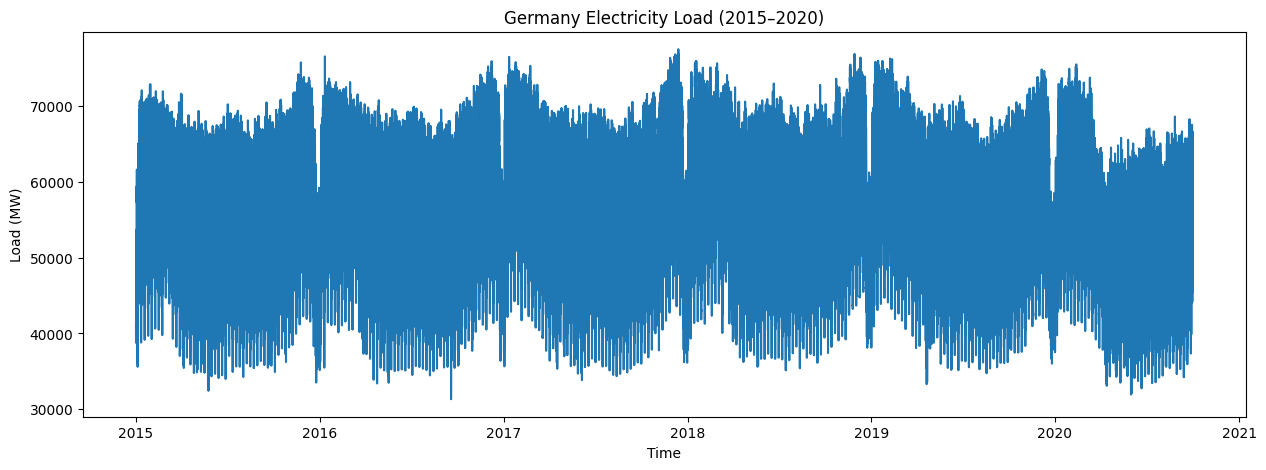

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(
    grid_selected['utc_timestamp'],
    grid_selected['DE_load_actual_entsoe_transparency']
)

plt.title("Germany Electricity Load (2015–2020)")
plt.xlabel("Time")

plt.ylabel("Load (MW)")

plt.show()

In [10]:
grid_selected[
    'DE_LU_price_day_ahead'
].isnull().groupby(
    grid_selected['utc_timestamp'].dt.year
).mean()*100

utc_timestamp
2014    100.000000
2015    100.000000
2016    100.000000
2017    100.000000
2018     74.783105
2019      0.022831
2020      0.045620
Name: DE_LU_price_day_ahead, dtype: float64

In [11]:
grid_selected.loc[
    grid_selected[
        'DE_load_actual_entsoe_transparency'
    ].nsmallest(20).index
][[
    'utc_timestamp',
    'DE_load_actual_entsoe_transparency'
]]

,utc_timestamp,DE_load_actual_entsoe_transparency
15026,2016-09-18 01:00:00+00:00,31307.0
15027,2016-09-18 02:00:00+00:00,31335.0
15025,2016-09-18 00:00:00+00:00,31598.0
15028,2016-09-18 03:00:00+00:00,31772.0
47452,2020-05-31 03:00:00+00:00,31923.0
47474,2020-06-01 01:00:00+00:00,32040.0
47451,2020-05-31 02:00:00+00:00,32397.0
3458,2015-05-25 01:00:00+00:00,32418.0
47453,2020-05-31 04:00:00+00:00,32507.0
47476,2020-06-01 03:00:00+00:00,32592.0


# Weather Dataset Plan

Source:
Open-Meteo Historical API

Variables Needed:

temperature_C

humidity_pct

cloud_cover_pct

wind_speed_ms

precipitation_mm

Location:

Germany (national representative weather)

In [12]:
cities = {
    'berlin':(52.52,13.405),
    'hamburg':(53.5511,9.9937),
    'munich':(48.1351,11.5820),
    'frankfurt':(50.1109,8.6821),
    'cologne':(50.9375,6.9603)
}

cities

{'berlin': (52.52, 13.405),
 'hamburg': (53.5511, 9.9937),
 'munich': (48.1351, 11.582),
 'frankfurt': (50.1109, 8.6821),
 'cologne': (50.9375, 6.9603)}

In [13]:
weather_variables = [
    "temperature_2m",
    "relative_humidity_2m",
    "cloud_cover",
    "wind_speed_10m",
    "precipitation"
]

weather_variables

['temperature_2m',
 'relative_humidity_2m',
 'cloud_cover',
 'wind_speed_10m',
 'precipitation']

In [14]:
import requests

In [15]:
def fetch_weather(city,
                  latitude,
                  longitude):

    url = (
        "https://archive-api.open-meteo.com/v1/archive"
    )

    params = {
        "latitude":latitude,
        "longitude":longitude,

        "start_date":"2015-01-01",
        "end_date":"2020-10-31",

        "hourly":[
            "temperature_2m",
            "relative_humidity_2m",
            "cloud_cover",
            "wind_speed_10m",
            "precipitation"
        ],

        "timezone":"UTC"
    }

    response = requests.get(
        url,
        params=params
    )

    return response.json()

In [16]:
berlin = fetch_weather(
    "berlin",
    52.52,
    13.405
)

berlin.keys()

dict_keys(['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'hourly_units', 'hourly'])

In [17]:
berlin['hourly'].keys()

dict_keys(['time', 'temperature_2m', 'relative_humidity_2m', 'cloud_cover', 'wind_speed_10m', 'precipitation'])

In [18]:
berlin_df = pd.DataFrame(
    berlin['hourly']
)

berlin_df.head()

,time,temperature_2m,relative_humidity_2m,cloud_cover,wind_speed_10m,precipitation
0,2015-01-01T00:00,3.8,96,71,14.4,0.0
1,2015-01-01T01:00,3.6,95,69,14.9,0.0
2,2015-01-01T02:00,3.3,94,95,14.6,0.0
3,2015-01-01T03:00,3.0,94,82,14.1,0.0
4,2015-01-01T04:00,2.3,94,67,13.0,0.0


### Automate all 5 Germany cities.

In [19]:
weather_frames = {}

for city, coords in cities.items():

    lat, lon = coords

    weather_json = fetch_weather(
        city,
        lat,
        lon
    )

    city_df = pd.DataFrame(
        weather_json['hourly']
    )

    weather_frames[city] = city_df

print(
    weather_frames.keys()
)

dict_keys(['berlin', 'hamburg', 'munich', 'frankfurt', 'cologne'])


### Validate with Hamburg before proceeding

In [20]:
weather_frames[
    'hamburg'
].head()

,time,temperature_2m,relative_humidity_2m,cloud_cover,wind_speed_10m,precipitation
0,2015-01-01T00:00,2.3,91,16,15.4,0.0
1,2015-01-01T01:00,1.9,92,31,15.5,0.0
2,2015-01-01T02:00,2.1,92,29,16.0,0.0
3,2015-01-01T03:00,1.9,93,85,16.7,0.0
4,2015-01-01T04:00,1.9,93,91,18.0,0.0


### Saving raw data files

In [21]:
for city, df in weather_frames.items():

    save_path = (
        WEATHER_PATH /
        city /
        f"{city}_weather.csv"
    )

    df.to_csv(
        save_path,
        index=False
    )

print(
    "Weather files saved."
)

Weather files saved.


In [22]:
pd.read_csv(
    "../data/raw/weather/munich/munich_weather.csv"
).head()

,time,temperature_2m,relative_humidity_2m,cloud_cover,wind_speed_10m,precipitation
0,2015-01-01T00:00,-4.8,93,91,5.5,0.0
1,2015-01-01T01:00,-5.2,93,91,5.7,0.0
2,2015-01-01T02:00,-5.4,93,94,6.5,0.0
3,2015-01-01T03:00,-4.6,92,92,4.1,0.0
4,2015-01-01T04:00,-4.0,91,96,5.8,0.0


## Germany national weather indicators

In [23]:
for city, df in weather_frames.items():

    df.rename(
        columns={
            'temperature_2m':
            f'{city}_temperature',

            'relative_humidity_2m':
            f'{city}_humidity',

            'cloud_cover':
            f'{city}_cloud_cover',

            'wind_speed_10m':
            f'{city}_wind_speed',

            'precipitation':
            f'{city}_precipitation'
        },

        inplace=True
    )

In [24]:
weather_merged = (
    weather_frames['berlin']
)

for city in [
    'hamburg',
    'munich',
    'frankfurt',
    'cologne'
]:

    weather_merged = (
        weather_merged.merge(
            weather_frames[city],

            on='time',

            how='inner'
        )
    )

weather_merged.shape

(51144, 26)

### Comparing number of rows between electricity and weather dataset (Weather coverage
### vs Electricity coverage)

In [25]:
print(
    weather_merged['time'].min()
)

print(
    weather_merged['time'].max()
)

2015-01-01T00:00
2020-10-31T23:00


In [26]:
print(
    grid_selected[
        'utc_timestamp'
    ].min()
)

print(
    grid_selected[
        'utc_timestamp'
    ].max()
)

2014-12-31 23:00:00+00:00
2020-09-30 23:00:00+00:00


### Alligning timestamps

In [27]:
weather_merged['time'] = pd.to_datetime(
    weather_merged['time'],
    utc=True
)

weather_merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 51144 entries, 0 to 51143
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype              
---  ------                   --------------  -----              
 0   time                     51144 non-null  datetime64[us, UTC]
 1   berlin_temperature       51144 non-null  float64            
 2   berlin_humidity          51144 non-null  int64              
 3   berlin_cloud_cover       51144 non-null  int64              
 4   berlin_wind_speed        51144 non-null  float64            
 5   berlin_precipitation     51144 non-null  float64            
 6   hamburg_temperature      51144 non-null  float64            
 7   hamburg_humidity         51144 non-null  int64              
 8   hamburg_cloud_cover      51144 non-null  int64              
 9   hamburg_wind_speed       51144 non-null  float64            
 10  hamburg_precipitation    51144 non-null  float64            
 11  munich_temperature       51144 non-null

In [28]:
weather_merged = weather_merged[
    (
        weather_merged['time']
        >=
        grid_selected[
            'utc_timestamp'
        ].min()
    )

    &

    (
        weather_merged['time']
        <=
        grid_selected[
            'utc_timestamp'
        ].max()
    )
]

weather_merged.shape

(50400, 26)

#### Creating Germany national weather indicators

In [29]:
weather_merged[
    'temperature_C'
] = weather_merged[
    [
        'berlin_temperature',
        'hamburg_temperature',
        'munich_temperature',
        'frankfurt_temperature',
        'cologne_temperature'
    ]
].mean(axis=1)


weather_merged[
    'humidity_pct'
] = weather_merged[
    [
        'berlin_humidity',
        'hamburg_humidity',
        'munich_humidity',
        'frankfurt_humidity',
        'cologne_humidity'
    ]
].mean(axis=1)


weather_merged[
    'cloud_cover_pct'
] = weather_merged[
    [
        'berlin_cloud_cover',
        'hamburg_cloud_cover',
        'munich_cloud_cover',
        'frankfurt_cloud_cover',
        'cologne_cloud_cover'
    ]
].mean(axis=1)


weather_merged[
    'wind_speed_ms'
] = weather_merged[
    [
        'berlin_wind_speed',
        'hamburg_wind_speed',
        'munich_wind_speed',
        'frankfurt_wind_speed',
        'cologne_wind_speed'
    ]
].mean(axis=1)


weather_merged[
    'precipitation_mm'
] = weather_merged[
    [
        'berlin_precipitation',
        'hamburg_precipitation',
        'munich_precipitation',
        'frankfurt_precipitation',
        'cologne_precipitation'
    ]
].mean(axis=1)

#### Veryfying...

In [30]:
weather_merged[
    [
        'temperature_C',
        'humidity_pct',
        'cloud_cover_pct',
        'wind_speed_ms',
        'precipitation_mm'
    ]
].head()

,temperature_C,humidity_pct,cloud_cover_pct,wind_speed_ms,precipitation_mm
0,0.96,94.4,67.4,8.50,0.0
1,0.62,94.4,67.8,8.72,0.0
2,0.44,94.0,71.0,8.84,0.0
3,0.42,94.2,79.2,8.52,0.0
4,0.18,94.2,83.6,9.34,0.0


### Merge Weather and electricity data

In [31]:
master = grid_selected.merge(
    weather_merged[
        [
            'time',

            'temperature_C',
            'humidity_pct',
            'cloud_cover_pct',
            'wind_speed_ms',
            'precipitation_mm'
        ]
    ],

    left_on='utc_timestamp',

    right_on='time',

    how='inner'
)

In [32]:
master.shape

(50400, 13)

In [33]:
master.head()

,utc_timestamp,DE_load_actual_entsoe_transparency,DE_solar_generation_actual,DE_wind_generation_actual,DE_solar_capacity,DE_wind_capacity,DE_LU_price_day_ahead,time,temperature_C,humidity_pct,cloud_cover_pct,wind_speed_ms,precipitation_mm
0,2015-01-01 00:00:00+00:00,41151.0,NaN,8852.0,37248.0,27913.0,NaN,2015-01-01 00:00:00+00:00,0.96,94.4,67.4,8.50,0.0
1,2015-01-01 01:00:00+00:00,40135.0,NaN,9054.0,37248.0,27913.0,NaN,2015-01-01 01:00:00+00:00,0.62,94.4,67.8,8.72,0.0
2,2015-01-01 02:00:00+00:00,39106.0,NaN,9070.0,37248.0,27913.0,NaN,2015-01-01 02:00:00+00:00,0.44,94.0,71.0,8.84,0.0
3,2015-01-01 03:00:00+00:00,38765.0,NaN,9163.0,37248.0,27913.0,NaN,2015-01-01 03:00:00+00:00,0.42,94.2,79.2,8.52,0.0
4,2015-01-01 04:00:00+00:00,38941.0,NaN,9231.0,37248.0,27913.0,NaN,2015-01-01 04:00:00+00:00,0.18,94.2,83.6,9.34,0.0


#### Validation checks

In [34]:
master.isnull().sum()

utc_timestamp                             0
DE_load_actual_entsoe_transparency        0
DE_solar_generation_actual              103
DE_wind_generation_actual                74
DE_solar_capacity                      6601
DE_wind_capacity                       6601
DE_LU_price_day_ahead                 32860
time                                      0
temperature_C                             0
humidity_pct                              0
cloud_cover_pct                           0
wind_speed_ms                             0
precipitation_mm                          0
dtype: int64

In [35]:
master.describe()

,DE_load_actual_entsoe_transparency,DE_solar_generation_actual,DE_wind_generation_actual,DE_solar_capacity,DE_wind_capacity,DE_LU_price_day_ahead,temperature_C,humidity_pct,cloud_cover_pct,wind_speed_ms,precipitation_mm
count,50400.000000,50297.000000,50326.000000,43799.000000,43799.000000,17540.000000,50400.000000,50400.000000,50400.000000,50400.000000,50400.000000
mean,55492.468552,4566.042905,11552.234650,42378.132240,39972.882098,35.809288,10.962404,75.036333,64.560901,12.061592,0.087590
std,10015.431042,6940.267590,9076.350769,4306.371168,7262.640092,18.137177,7.694055,14.524631,25.889932,4.986269,0.176042
min,31307.000000,0.000000,135.000000,37248.000000,27913.000000,-90.010000,-12.040000,23.600000,0.000000,1.560000,0.000000
25%,47106.000000,0.000000,4506.000000,38810.000000,33737.000000,26.717500,4.820000,65.400000,47.400000,8.460000,0.000000
50%,55092.000000,173.000000,9015.000000,40941.000000,39808.000000,36.150000,10.560000,78.400000,68.600000,10.940000,0.000000
75%,64309.250000,7342.000000,16113.750000,46092.000000,47730.000000,46.030000,16.760000,86.600000,85.200000,14.500000,0.100000
max,77549.000000,32947.000000,46064.000000,50508.000000,50452.000000,200.040000,35.900000,99.000000,100.000000,40.920000,3.760000
